# Bank Customer Churn Analysis
## Data Preprocessing


In [174]:
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score, f1_score, accuracy_score, roc_curve, RocCurveDisplay, precision_recall_curve, PrecisionRecallDisplay, average_precision_score
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from metrics import print_binary_classification_metrics

In [147]:
bank = pd.read_csv('./Bank Customer Churn Prediction.csv')
bank.head(5)

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [148]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [149]:
bank.isnull().sum()

customer_id         0
credit_score        0
country             0
gender              0
age                 0
tenure              0
balance             0
products_number     0
credit_card         0
active_member       0
estimated_salary    0
churn               0
dtype: int64

In [150]:
bank['country'].value_counts()

country
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [203]:
## DataFrame에서 X, y 분리
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

cate_item = ['country','gender']
numeric_item = ['customer_id','credit_score','age','tenure','balance','products_number','credit_card','active_member','estimated_salary']

target = ['churn']
cate_index = [2,3]
num_index = [0, 1, 4, 5,6,7,8,9,10]

tscv = TimeSeriesSplit(n_splits=5)


bank['country'] = LabelEncoder().fit_transform(bank['country'])
bank['gender'] = LabelEncoder().fit_transform(bank['gender'])
bank['churn'] = LabelEncoder().fit_transform(bank['churn'])

y = bank['churn']
X = bank.drop(columns='churn')

X.shape, y.shape




((10000, 11), (10000,))

In [152]:
#y = bank['churn'].values.reshape(-1,1)
#X = bank.drop(columns="churn").values

In [204]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=10,stratify=y)
X_train.shape, X_test.shape



((7500, 11), (2500, 11))

In [168]:
'''
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

# 범주형 컬럼 전처리 파이프라인
cate_preprocessing = Pipeline([("ohe", OneHotEncoder(handle_unknown="ignore"))])

# 수치형 컬럼 전처리 파이프라인
num_preprocessing = Pipeline([("scaler", StandardScaler())])

# ColumnTransformer로 컬럼별로 전처리 파이프라인 정의.
preprocessing = ColumnTransformer([
    ("category", cate_preprocessing, cate_index),
    ("number", num_preprocessing, num_index)
])
# preprocessing
# 전처리기와 모델을 묶는 파이프라인

pipeline = Pipeline([
    ("preprocessor", preprocessing),
    ("model", LogisticRegression(max_iter=2000))
])
'''


In [ ]:
# pipeline.fit(X_train, y_train)

In [ ]:
# print_binary_classification_metrics(y_test,pipeline.predict(X_test), pipeline.predict_proba(X_test)[:, 0], "Pipeline Test set")

### K_fold

In [17]:
'''
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_validate, StratifiedKFold

sf = StratifiedKFold(n_splits=4)
s_gen = sf.split(X, y)
train_idx, valid_idx = next(s_gen)

np.unique(y[train_idx], return_counts=True)
np.unique(y[valid_idx], return_counts=True)

s_kfold = StratifiedKFold(n_splits=4)
s_gen = s_kfold.split(X, y)


max_depth_list = [i for i in range(1,11)]
results = {"max_depth": [], "scores": [], "mean_score": []}


val_result = []
for train_idx, test_idx in s_gen:

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    print("X type: ", type(X_train))
    # 모델링
    max_depth = 5

    model = DecisionTreeClassifier(max_depth=max_depth, random_state=10)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    val_result.append(accuracy_score(y_test, pred))


print("StratifiedKFold: decision tree validation_result")
print(val_result)
'''


X type:  <class 'numpy.ndarray'>
X type:  <class 'numpy.ndarray'>
X type:  <class 'numpy.ndarray'>
X type:  <class 'numpy.ndarray'>
StratifiedKFold: decision tree validation_result
[0.8492, 0.8596, 0.8536, 0.8496]


## Decision Tree

In [243]:
##### DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=10)


param_tree = { 'max_features': ['sqrt', 'log2'],
               'max_depth': [3, 5, 7],
               'min_samples_split': [2, 5, 8],
               'min_samples_leaf':[1, 2, 4, 8],
               'class_weight': ['balanced']
}

tree_random = RandomizedSearchCV(estimator = tree,
                                param_distributions = param_tree,
                                n_iter = 5,
                                verbose=2,
                                scoring='roc_auc',
                                random_state=10,
                                n_jobs = -1)

tree_random.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,DecisionTreeC...ndom_state=10)
,param_distributions,"{'class_weight': ['balanced'], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,5
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,10
,error_score,nan


In [244]:
best_tree = tree_random.best_estimator_
print("Best Parameter (Decision Tree):", tree_random.best_params_)

y_predict_tree = best_tree.predict(X_test)
y_proba_tree = best_tree.predict_proba(X_test)[:, 1]

tree_accuracy = accuracy_score(y_test, y_predict_tree)
tree_f1 = f1_score(y_test, y_predict_tree)
tree_roc_auc = roc_auc_score(y_test, y_proba_tree)
print(f"Accuracy : {tree_accuracy:.6f}")
print(f"F1-score : {tree_f1:.6f}")
print(f"ROC-AUC  : {tree_roc_auc:.6f}")

Best Parameter (Decision Tree): {'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 'log2', 'max_depth': 7, 'class_weight': 'balanced'}
Accuracy : 0.749200
F1-score : 0.544662
ROC-AUC  : 0.820087


In [245]:
print_binary_classification_metrics(
    y_test, y_predict_tree, y_proba_tree, "Random Forest Prediction"
)

Random Forest Prediction
정확도: 0.7492
재현율: 0.7367387033398821
정밀도: 0.43202764976958524
F1 점수: 0.5446623093681917
Average Precision: 0.6253076123212808
ROC-AUC Score: 0.8200872492029455


In [246]:
print("---------------Decision Tree Test set Classification Report---------------")
print(classification_report(y_test, y_predict_tree))

---------------Decision Tree Test set Classification Report---------------
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      1991
           1       0.43      0.74      0.54       509

    accuracy                           0.75      2500
   macro avg       0.67      0.74      0.69      2500
weighted avg       0.82      0.75      0.77      2500



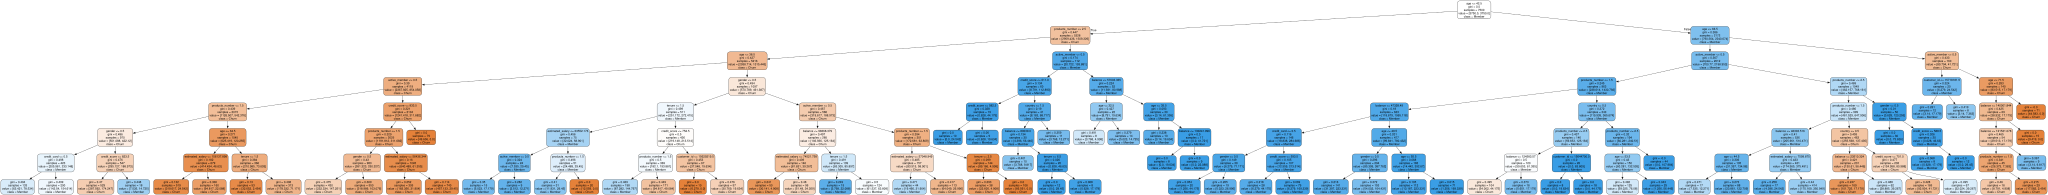

In [247]:
from sklearn.tree import export_graphviz
from graphviz import Source

graph = Source(
    export_graphviz(
        best_tree,
        feature_names=bank.columns[:-1],
        class_names=['Churn', 'Member'],
        filled=True,
        rounded=True
    )
)
graph

## Random Forest

In [248]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=10)


param_rf = {'n_estimators': [100, 300, 500, 700, 900],
               'max_features': ['sqrt', 'log2'],
               'max_depth': [3, 5, 7,9],
               'min_samples_split': [2, 5, 8],
               'min_samples_leaf':[1, 2, 4, 8],
               'bootstrap': [True, False],
               'class_weight': ['balanced', 'balanced_subsample']
            }


rf_random = RandomizedSearchCV(estimator = rfc,
                               param_distributions = param_rf,
                               n_iter = 5,
                               scoring='roc_auc',
                               verbose=2,
                               random_state=10,
                               n_jobs = -1)


rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,RandomForestC...ndom_state=10)
,param_distributions,"{'bootstrap': [True, False], 'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [3, 5, ...], 'max_features': ['sqrt', 'log2'], ...}"
,n_iter,5
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,10
,error_score,nan


In [249]:
best_random_forest = rf_random.best_estimator_
print("Best Parameter (Random Forest):", rf_random.best_params_)

y_predict_rf = best_random_forest.predict(X_test)
y_proba_rf = best_random_forest.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, y_predict_rf)
rf_f1 = f1_score(y_test, y_predict_rf)
rf_roc_auc = roc_auc_score(y_test, y_proba_rf)
print(f"Accuracy : {rf_accuracy:.6f}")
print(f"F1-score : {rf_f1:.6f}")
print(f"ROC-AUC  : {rf_roc_auc:.6f}")

Best Parameter (Random Forest): {'n_estimators': 900, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 9, 'class_weight': 'balanced', 'bootstrap': False}
Accuracy : 0.809200
F1-score : 0.601504
ROC-AUC  : 0.858197


In [250]:
print_binary_classification_metrics(
    y_test, y_predict_rf, y_proba_rf, "Random Forest Prediction"
)

Random Forest Prediction
정확도: 0.8092
재현율: 0.7072691552062869
정밀도: 0.5232558139534884
F1 점수: 0.6015037593984962
Average Precision: 0.6821574545186967
ROC-AUC Score: 0.8581968563841806


In [251]:
print(classification_report(y_test, y_predict_rf))

              precision    recall  f1-score   support

           0       0.92      0.84      0.87      1991
           1       0.52      0.71      0.60       509

    accuracy                           0.81      2500
   macro avg       0.72      0.77      0.74      2500
weighted avg       0.84      0.81      0.82      2500



## XGBoost

In [230]:
from xgboost import XGBClassifier
xgb = XGBClassifier(random_state=10, objective='binary:logistic',eval_metric='logloss', tree_method='approx')


param_xgb = {'n_estimators': [200, 300, 500],
               'booster':['gbtree','gblinear'],
               'learning_rate': [0.01, 0.5, 0.1],
               'max_depth': [3, 5, 7],
               'colsample_bytree': [0.5, 0.6, 0.7],
               "gamma"       : [1, 2, 3]
}

xgbc = RandomizedSearchCV(estimator = xgb,
                    param_distributions = param_xgb,
                   n_iter = 5,
                   verbose=2,
                   random_state=10,
                   n_jobs = -1)


xgbc.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'booster': ['gbtree', 'gblinear'], 'colsample_bytree': [0.5, 0.6, ...], 'gamma': [1, 2, ...], 'learning_rate': [0.01, 0.5, ...], ...}"
,n_iter,5
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,10
,error_score,nan


In [231]:
best_xgb = xgbc.best_estimator_
print("Best parameters (XGBoost):", best_xgb)

y_predict_xgb = best_xgb.predict(X_test)
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, y_predict_xgb)
xgb_f1 = f1_score(y_test, y_predict_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_proba_xgb)
print(f"Accuracy : {xgb_accuracy:.6f}")
print(f"F1-score : {xgb_f1:.6f}")
print(f"ROC-AUC  : {xgb_roc_auc:.6f}")


Best parameters (XGBoost): XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)
Accuracy : 0.868400
F1-score : 0.594328
ROC-AUC  : 0.865592


In [232]:
print_binary_classification_metrics(
    y_test, y_predict_xgb, y_proba_xgb, "XGBoost Results"
)

XGBoost Results
정확도: 0.8684
재현율: 0.47347740667976423
정밀도: 0.7980132450331126
F1 점수: 0.594327990135635
Average Precision: 0.7102104974965497
ROC-AUC Score: 0.8655921193504365


In [95]:
pd.Series(best_xgb.feature_importances_).sort_values(ascending=False)

7     0.268530
4     0.231602
9     0.216246
3     0.067368
2     0.057153
6     0.049871
8     0.024303
0     0.022863
1     0.021293
5     0.020837
10    0.019934
dtype: float32

## Light GBM

In [233]:
from lightgbm import LGBMClassifier
lgbm = LGBMClassifier(random_state=10, objective='binary',eval_metric='logloss', tree_method='approx')

param_lgbm = {'n_estimators': [300, 500, 700],
            'boosting type':['gbtree','gblinear'],
            'learning_rate': [0.01, 0.5, 0.1],
            'max_depth': [5, 7,9],
            'colsample_bytree': [0.5, 0.7, 0.9],
            'subsample': [0.6, 0.8, 1.0],
            'feature_fraction': [0.5,0.6,0.7],
            'bagging_fraction': [0.5,0.6,0.7]
}


lgbm_cv = RandomizedSearchCV(estimator = lgbm,
                    param_distributions = param_lgbm,
                   n_iter = 5,
                   verbose=2,
                   random_state=10,
                   n_jobs = -1)



lgbm_cv.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


,estimator,LGBMClassifie...thod='approx')
,param_distributions,"{'bagging_fraction': [0.5, 0.6, ...], 'boosting type': ['gbtree', 'gblinear'], 'colsample_bytree': [0.5, 0.7, ...], 'feature_fraction': [0.5, 0.6, ...], ...}"
,n_iter,5
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,10
,error_score,nan


In [234]:
best_lgbm = lgbm_cv.best_estimator_
print("Best parameters (Light BGM):", best_lgbm)

y_predict_lgbm = best_lgbm.predict(X_test)
y_proba_lgbm = best_lgbm.predict_proba(X_test)[:, 1]

lgbm_accuracy = accuracy_score(y_test, y_predict_lgbm)
lgbm_f1 = f1_score(y_test, y_predict_lgbm)
lgbm_roc_auc = roc_auc_score(y_test, y_proba_lgbm)
print(f"Accuracy : {lgbm_accuracy:.6f}")
print(f"F1-score : {lgbm_f1:.6f}")
print(f"ROC-AUC  : {lgbm_roc_auc:.6f}")

Best parameters (Light BGM): LGBMClassifier(bagging_fraction=0.5, boosting type='gblinear',
               colsample_bytree=0.9, eval_metric='logloss',
               feature_fraction=0.5, max_depth=9, n_estimators=300,
               objective='binary', random_state=10, tree_method='approx')
Accuracy : 0.860000
F1-score : 0.579327
ROC-AUC  : 0.848040


In [235]:
print_binary_classification_metrics(
    y_test, y_predict_lgbm, y_proba_lgbm, "Light GBM Results"
)

Light GBM Results
정확도: 0.86
재현율: 0.47347740667976423
정밀도: 0.7461300309597523
F1 점수: 0.5793269230769231
Average Precision: 0.6855014691260484
ROC-AUC Score: 0.8480401492373835


In [236]:
pd.Series(best_lgbm.feature_importances_).sort_values(ascending=False)

10    1610
1     1552
0     1454
6     1286
4     1129
5      738
2      331
7      296
9      220
3      207
8      149
dtype: int32

## CatBoost

In [240]:
from catboost import CatBoostClassifier
cat = CatBoostClassifier(random_state=10, eval_metric='AUC', loss_function='Logloss')


param_cat = {'n_estimators': [200,400,600],'learning_rate': [0.05, 0.1], 'depth': [5, 7, 9]}

cat_cv = RandomizedSearchCV(estimator = cat,
                   param_distributions = param_cat,
                   scoring='roc_auc',
                   n_iter = 5,
                   verbose=2,
                   random_state=10,
                   n_jobs = -1
)


cat_cv.fit(X_train, y_train)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
0:	total: 6.33ms	remaining: 1.26s
1:	total: 10.8ms	remaining: 1.07s
2:	total: 16.9ms	remaining: 1.11s
3:	total: 22.5ms	remaining: 1.1s
4:	total: 28.6ms	remaining: 1.11s
5:	total: 33.5ms	remaining: 1.08s
6:	total: 39.9ms	remaining: 1.1s
7:	total: 44.7ms	remaining: 1.07s
8:	total: 50.1ms	remaining: 1.06s
9:	total: 55.2ms	remaining: 1.05s
10:	total: 59.7ms	remaining: 1.03s
11:	total: 64ms	remaining: 1s
12:	total: 68.3ms	remaining: 982ms
13:	total: 71.9ms	remaining: 955ms
14:	total: 75.6ms	remaining: 933ms
15:	total: 79.2ms	remaining: 911ms
16:	total: 82.7ms	remaining: 890ms
17:	total: 86.1ms	remaining: 871ms
18:	total: 89.5ms	remaining: 853ms
19:	total: 92.7ms	remaining: 834ms
20:	total: 96ms	remaining: 818ms
21:	total: 99.2ms	remaining: 803ms
22:	total: 102ms	remaining: 788ms
23:	total: 106ms	remaining: 775ms
24:	total: 109ms	remaining: 762ms
25:	total: 112ms	remaining: 751ms
26:	total: 115ms	remaining: 738ms
27:	total: 118ms	re

,estimator,<catboost.cor...0013AC70620F0>
,param_distributions,"{'depth': [5, 7, ...], 'learning_rate': [0.05, 0.1], 'n_estimators': [200, 400, ...]}"
,n_iter,5
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,None
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,10
,error_score,nan


In [266]:
best_cat = cat_cv.best_estimator_
print("Best parameters (Cat Boost):", best_cat)

y_predict_cat = best_cat.predict(X_test)
y_proba_cat = best_cat.predict_proba(X_test)[:, 1]

cat_accuracy = accuracy_score(y_test, y_predict_cat)
cat_f1 = f1_score(y_test, y_predict_cat)
cat_roc_auc = roc_auc_score(y_test, y_proba_cat)
print(f"Accuracy : {cat_accuracy:.6f}")
print(f"F1-score : {cat_f1:.6f}")
print(f"ROC-AUC  : {cat_roc_auc:.6f}")

Best parameters (Cat Boost): <catboost.core.CatBoostClassifier object at 0x0000013AC70630B0>
Accuracy : 0.862000
F1-score : 0.577723
ROC-AUC  : 0.868038


In [267]:
print_binary_classification_metrics(
    y_test, y_predict_cat, y_proba_cat, "Cat Boost Results"
)

Cat Boost Results
정확도: 0.862
재현율: 0.4636542239685658
정밀도: 0.7662337662337663
F1 점수: 0.5777233782129743
Average Precision: 0.7163475211003277
ROC-AUC Score: 0.8680378007517127


## Optuna

In [254]:
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):

    classifier_name = trial.suggest_categorical('classifier', ['XGBoost', 'CatBoost', 'LightGBM'])

    if classifier_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 700),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1),
            'random_state': 10
        }
        classifier_obj = XGBClassifier(**params)


    elif classifier_name == 'CatBoost':
        params = {
            'iterations': trial.suggest_int('iterations', 200, 600),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
            'depth': trial.suggest_int('depth', 3, 8),
            'random_state': 10,
        }
        classifier_obj = CatBoostClassifier(**params)


    elif classifier_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 300, 700),
            'max_depth': trial.suggest_int('max_depth', 3, 7),
            'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.1),
            'random_state': 10
        }
        classifier_obj = LGBMClassifier(**params)

    accuracy = cross_val_score(classifier_obj, X_train, y_train, scoring='f1').mean()

    return accuracy


In [271]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)
print("Best Model:", study.best_params['classifier'])

[I 2025-11-24 16:25:01,311] A new study created in memory with name: no-name-e7d99e70-9069-4f86-8774-d6b326ad879f


0:	learn: 0.6752264	total: 2.35ms	remaining: 1.01s
1:	learn: 0.6557485	total: 4.49ms	remaining: 963ms
2:	learn: 0.6385058	total: 6.91ms	remaining: 986ms
3:	learn: 0.6209816	total: 9.1ms	remaining: 971ms
4:	learn: 0.6048267	total: 11.4ms	remaining: 971ms
5:	learn: 0.5895596	total: 13.4ms	remaining: 950ms
6:	learn: 0.5767716	total: 15.4ms	remaining: 933ms
7:	learn: 0.5627165	total: 18.2ms	remaining: 961ms
8:	learn: 0.5526859	total: 20.5ms	remaining: 963ms
9:	learn: 0.5435370	total: 23.2ms	remaining: 976ms
10:	learn: 0.5323984	total: 25.2ms	remaining: 962ms
11:	learn: 0.5230062	total: 26.7ms	remaining: 933ms
12:	learn: 0.5150273	total: 28.6ms	remaining: 921ms
13:	learn: 0.5067266	total: 30.6ms	remaining: 911ms
14:	learn: 0.4974925	total: 32.5ms	remaining: 900ms
15:	learn: 0.4891208	total: 34.4ms	remaining: 893ms
16:	learn: 0.4809849	total: 36.3ms	remaining: 885ms
17:	learn: 0.4748938	total: 38.4ms	remaining: 881ms
18:	learn: 0.4671737	total: 40.5ms	remaining: 879ms
19:	learn: 0.4606558	to

[I 2025-11-24 16:25:06,267] Trial 0 finished with value: 0.5862625751272541 and parameters: {'classifier': 'CatBoost', 'iterations': 431, 'learning_rate': 0.025381970679951037, 'depth': 6}. Best is trial 0 with value: 0.5862625751272541.


396:	learn: 0.2768228	total: 865ms	remaining: 74.1ms
397:	learn: 0.2766335	total: 867ms	remaining: 71.9ms
398:	learn: 0.2765295	total: 870ms	remaining: 69.8ms
399:	learn: 0.2763348	total: 872ms	remaining: 67.6ms
400:	learn: 0.2761657	total: 875ms	remaining: 65.5ms
401:	learn: 0.2760699	total: 877ms	remaining: 63.3ms
402:	learn: 0.2759146	total: 880ms	remaining: 61.1ms
403:	learn: 0.2757776	total: 882ms	remaining: 58.9ms
404:	learn: 0.2756428	total: 884ms	remaining: 56.8ms
405:	learn: 0.2754831	total: 887ms	remaining: 54.6ms
406:	learn: 0.2752973	total: 889ms	remaining: 52.4ms
407:	learn: 0.2751464	total: 891ms	remaining: 50.2ms
408:	learn: 0.2748995	total: 893ms	remaining: 48ms
409:	learn: 0.2747533	total: 895ms	remaining: 45.8ms
410:	learn: 0.2746610	total: 897ms	remaining: 43.6ms
411:	learn: 0.2745304	total: 899ms	remaining: 41.5ms
412:	learn: 0.2744282	total: 901ms	remaining: 39.3ms
413:	learn: 0.2743508	total: 903ms	remaining: 37.1ms
414:	learn: 0.2740491	total: 905ms	remaining: 34

[I 2025-11-24 16:25:07,581] Trial 1 finished with value: 0.5691258290578192 and parameters: {'classifier': 'XGBoost', 'n_estimators': 526, 'max_depth': 6, 'learning_rate': 0.09190804495171237}. Best is trial 0 with value: 0.5862625751272541.
[I 2025-11-24 16:25:08,766] Trial 2 finished with value: 0.5724780298351204 and parameters: {'classifier': 'LightGBM', 'n_estimators': 552, 'max_depth': 6, 'learning_rate': 0.0850600240022446}. Best is trial 0 with value: 0.5862625751272541.
[I 2025-11-24 16:25:10,080] Trial 3 finished with value: 0.568372725331525 and parameters: {'classifier': 'LightGBM', 'n_estimators': 550, 'max_depth': 7, 'learning_rate': 0.06753076828194297}. Best is trial 0 with value: 0.5862625751272541.


0:	learn: 0.6850552	total: 1.83ms	remaining: 801ms
1:	learn: 0.6764881	total: 3.96ms	remaining: 866ms
2:	learn: 0.6683691	total: 5.82ms	remaining: 845ms
3:	learn: 0.6597568	total: 7.59ms	remaining: 826ms
4:	learn: 0.6530471	total: 9.33ms	remaining: 810ms
5:	learn: 0.6460352	total: 11ms	remaining: 797ms
6:	learn: 0.6375562	total: 12.9ms	remaining: 798ms
7:	learn: 0.6304399	total: 14.8ms	remaining: 795ms
8:	learn: 0.6225992	total: 16.6ms	remaining: 792ms
9:	learn: 0.6165258	total: 18.3ms	remaining: 784ms
10:	learn: 0.6112196	total: 19.9ms	remaining: 776ms
11:	learn: 0.6053369	total: 21.7ms	remaining: 773ms
12:	learn: 0.5983087	total: 23.6ms	remaining: 773ms
13:	learn: 0.5922511	total: 25.4ms	remaining: 773ms
14:	learn: 0.5856419	total: 27.4ms	remaining: 774ms
15:	learn: 0.5808044	total: 29.1ms	remaining: 770ms
16:	learn: 0.5744405	total: 31ms	remaining: 770ms
17:	learn: 0.5683930	total: 32.8ms	remaining: 768ms
18:	learn: 0.5630798	total: 34.8ms	remaining: 768ms
19:	learn: 0.5580299	total

[I 2025-11-24 16:25:13,642] Trial 4 finished with value: 0.5464189627482041 and parameters: {'classifier': 'CatBoost', 'iterations': 439, 'learning_rate': 0.012954793287073, 'depth': 3}. Best is trial 0 with value: 0.5862625751272541.


308:	learn: 0.3468494	total: 441ms	remaining: 185ms
309:	learn: 0.3468111	total: 442ms	remaining: 184ms
310:	learn: 0.3467340	total: 443ms	remaining: 182ms
311:	learn: 0.3466590	total: 445ms	remaining: 181ms
312:	learn: 0.3465805	total: 447ms	remaining: 180ms
313:	learn: 0.3464248	total: 448ms	remaining: 178ms
314:	learn: 0.3463442	total: 449ms	remaining: 177ms
315:	learn: 0.3462798	total: 450ms	remaining: 175ms
316:	learn: 0.3461742	total: 451ms	remaining: 174ms
317:	learn: 0.3461107	total: 453ms	remaining: 172ms
318:	learn: 0.3460345	total: 454ms	remaining: 171ms
319:	learn: 0.3459321	total: 455ms	remaining: 169ms
320:	learn: 0.3457990	total: 456ms	remaining: 168ms
321:	learn: 0.3456635	total: 458ms	remaining: 166ms
322:	learn: 0.3455799	total: 459ms	remaining: 165ms
323:	learn: 0.3454487	total: 460ms	remaining: 163ms
324:	learn: 0.3453191	total: 462ms	remaining: 162ms
325:	learn: 0.3452072	total: 464ms	remaining: 161ms
326:	learn: 0.3451050	total: 465ms	remaining: 159ms
327:	learn: 

[I 2025-11-24 16:25:14,368] Trial 5 finished with value: 0.5756689433815488 and parameters: {'classifier': 'XGBoost', 'n_estimators': 204, 'max_depth': 7, 'learning_rate': 0.07598037961629134}. Best is trial 0 with value: 0.5862625751272541.
[I 2025-11-24 16:25:15,485] Trial 6 finished with value: 0.5765030387557352 and parameters: {'classifier': 'XGBoost', 'n_estimators': 672, 'max_depth': 4, 'learning_rate': 0.0711283145198953}. Best is trial 0 with value: 0.5862625751272541.
[I 2025-11-24 16:25:17,708] Trial 7 finished with value: 0.5700929085008829 and parameters: {'classifier': 'XGBoost', 'n_estimators': 698, 'max_depth': 7, 'learning_rate': 0.05219741898418867}. Best is trial 0 with value: 0.5862625751272541.
[I 2025-11-24 16:25:19,725] Trial 8 finished with value: 0.569271796340561 and parameters: {'classifier': 'XGBoost', 'n_estimators': 502, 'max_depth': 8, 'learning_rate': 0.06114698958999533}. Best is trial 0 with value: 0.5862625751272541.
[I 2025-11-24 16:25:20,694] Trial 

Best Score: 0.5862625751272541
Best Params: {'classifier': 'CatBoost', 'iterations': 431, 'learning_rate': 0.025381970679951037, 'depth': 6}
Best Model: CatBoost


### Precision Recall Curve + AP Score

DecisionTree Average Precision Score: 0.37189149049822096
RandomForest Average Precision Score: 0.42968269749166177
XGBoost Average Precision Score: 0.4850412417543814
Light GBM Precision Score: 0.4604757121047157
CatBoost Precision Score: 0.4644675222616284


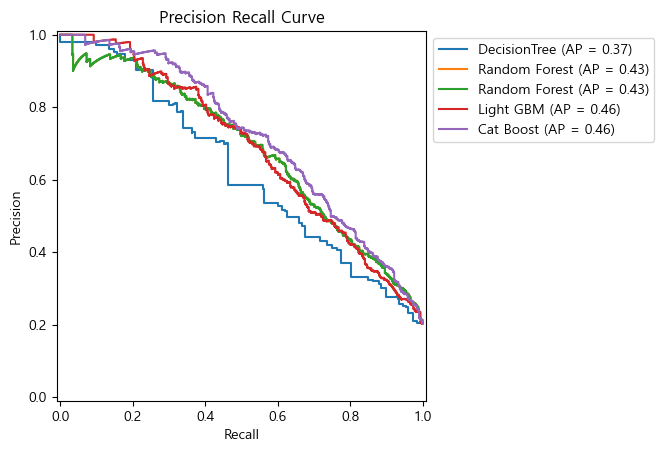

In [272]:
##### DecisionTree의 PrecisionRecall 커브 그리기 + AP Score 계산.
tree_ap = average_precision_score(y_test, y_predict_tree)  # (y정답, 모델이 예측한 이탈한 확률)
rfc_ap = average_precision_score(y_test, y_predict_rf)
xgb_ap = average_precision_score(y_test, y_predict_xgb)
lgbm_ap = average_precision_score(y_test, y_predict_lgbm)
cat_ap = average_precision_score(y_test, y_predict_cat)

print("DecisionTree Average Precision Score:", tree_ap)
print("RandomForest Average Precision Score:", rfc_ap)
print("XGBoost Average Precision Score:", xgb_ap)
print("Light GBM Precision Score:", lgbm_ap)
print("CatBoost Precision Score:", cat_ap)


precisions1, recalls1, _ = precision_recall_curve(y_test, y_proba_tree)
precisions2, recalls2, _ = precision_recall_curve(y_test, y_proba_rf)
precisions3, recalls3, _ = precision_recall_curve(y_test, y_proba_xgb)
precisions4, recalls4, _ = precision_recall_curve(y_test, y_proba_lgbm)
precisions5, recalls5, _ = precision_recall_curve(y_test, y_proba_cat)
ax = plt.gca()

disp_tree = PrecisionRecallDisplay(precisions1, recalls1,  average_precision=tree_ap, estimator_name="DecisionTree" )
disp_tree.plot(ax=ax)

disp_rfc = PrecisionRecallDisplay(precisions2, recalls2, average_precision=rfc_ap, estimator_name="Random Forest")
disp_rfc.plot(ax=ax)

disp_xgb = PrecisionRecallDisplay(precisions3, recalls3, average_precision=xgb_ap, estimator_name="XGBoost")
disp_rfc.plot(ax=ax)

disp_lgbm = PrecisionRecallDisplay(precisions4, recalls4, average_precision=lgbm_ap, estimator_name="Light GBM")
disp_lgbm.plot(ax=ax)

disp_cat = PrecisionRecallDisplay(precisions5, recalls5, average_precision=cat_ap, estimator_name="Cat Boost")
disp_cat.plot(ax=ax)

plt.title("Precision Recall Curve")
plt.legend(bbox_to_anchor=(1,1), loc="upper left")
plt.show()

ROC-AUC Curve


In [268]:
fpr1, recall1, thresh1 = roc_curve(y_test, y_proba_tree)
fpr2, recall2, thresh2 = roc_curve(y_test, y_proba_rf)
fpr3, recall3, thresh3 = roc_curve(y_test, y_proba_xgb)
fpr4, recall4, thresh4 = roc_curve(y_test, y_proba_lgbm)
fpr5, recall5, thresh5 = roc_curve(y_test, y_proba_cat)

pd.DataFrame({"Thresh": thresh1,"FPR":fpr1,"Recall":recall1})

,Thresh,FPR,Recall
0,inf,0.000000,0.000000
1,1.000000,0.000502,0.098232
2,0.992638,0.001005,0.135560
3,0.978235,0.001507,0.147348
4,0.972357,0.002009,0.157171
5,0.969009,0.002511,0.163065
6,0.964737,0.002511,0.178782
7,0.964245,0.004018,0.210216
8,0.944247,0.007032,0.255403
9,0.876745,0.017077,0.300589


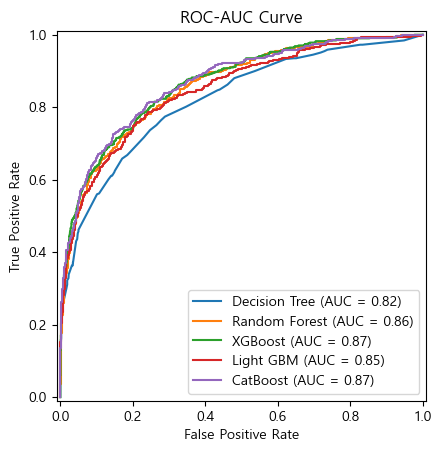

In [269]:
ax = plt.gca()
ax.set_title("ROC-AUC Curve")

disp_roc_tree = RocCurveDisplay(
    fpr=fpr1, tpr=recall1,
    roc_auc=tree_roc_auc,
    name="Decision Tree"
)
disp_roc_tree.plot(ax=ax)

disp_roc_rfc = RocCurveDisplay(
    fpr=fpr2, tpr=recall2,
    roc_auc=rf_roc_auc,
    name="Random Forest"
)
disp_roc_rfc.plot(ax=ax)

disp_roc_xgb = RocCurveDisplay(
    fpr=fpr3, tpr=recall3,
    roc_auc=xgb_roc_auc,
    name="XGBoost"
)
disp_roc_xgb.plot(ax=ax)

disp_roc_lgbm = RocCurveDisplay(
    fpr=fpr4, tpr=recall4,
    roc_auc=lgbm_roc_auc,
    name="Light GBM"
)
disp_roc_lgbm.plot(ax=ax)

disp_roc_cat = RocCurveDisplay(
    fpr=fpr5, tpr=recall5,
    roc_auc=cat_roc_auc,
    name="CatBoost"
)
disp_roc_cat.plot(ax=ax)


plt.show()

### Final

In [270]:
results = [{
        "모델": "Decision Tree",
        "F1-score": f'{tree_f1:.4f}',
        "Accuracy": f'{tree_accuracy:.4f}',
        "ROC-AUC": f'{tree_roc_auc:.4f}',
        "하이퍼파라미터": f'{tree_random.best_params_}'
},{
        "모델": "RandomForest",
        "F1-score": f'{rf_f1:.4f}',
        "Accuracy": f'{rf_accuracy:.4f}',
        "ROC-AUC": f'{rf_roc_auc:.4f}',
        "하이퍼파라미터": f'{rf_random.best_params_}'
},{
        "모델": "XGBoost",
        "F1-score": f'{xgb_f1:.4f}',
        "Accuracy": f'{xgb_accuracy:.4f}',
        "ROC-AUC": f'{xgb_roc_auc:.4f}',
        "하이퍼파라미터": f'{best_xgb}'
},{
        "모델": "LightGBM",
        "F1-score": f'{lgbm_f1:.4f}',
        "Accuracy": f'{lgbm_accuracy:.4f}',
        "ROC-AUC": f'{lgbm_roc_auc:.4f}',
        "하이퍼파라미터": f'{best_lgbm}'
},{
        "모델": "CatBoost",
        "F1-score": f'{cat_f1:.4f}',
        "Accuracy": f'{cat_accuracy:.4f}',
        "ROC-AUC": f'{cat_roc_auc:.4f}',
        "하이퍼파라미터": f'{best_cat}'
}]
df_results = pd.DataFrame(results)
df_results

,모델,F1-score,Accuracy,ROC-AUC,하이퍼파라미터
0,Decision Tree,0.5447,0.7492,0.8201,"{'min_samples_split': 2, 'min_samples_leaf': 8..."
1,RandomForest,0.6015,0.8092,0.8582,"{'n_estimators': 900, 'min_samples_split': 5, ..."
2,XGBoost,0.5943,0.8684,0.8656,"XGBClassifier(base_score=None, booster='gbtree..."
3,LightGBM,0.5793,0.8600,0.8480,"LGBMClassifier(bagging_fraction=0.5, boosting ..."
4,CatBoost,0.5777,0.8620,0.8680,<catboost.core.CatBoostClassifier object at 0x...
